# Remaining Features

Everything `explore.ipynb` hasn't covered: **Name**, **Ticket**, **Embarked**, a fare-per-person
variant, and interactions among features already in the pipeline. Same 80/20 stratified split as
`explore.ipynb`, so the numbers are comparable.

Works off `train_raw`: `Name` and `Ticket` are dropped by the cleaning pipeline before EDA sees them.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/train.csv")
train_raw, _ = train_test_split(
    df, test_size=0.2, stratify=df["Survived"], random_state=42
)


# "Braund, Mr. Owen Harris" -> "Mr". the four common titles carry the signal; the 18 rows of
# Dr/Rev/Col/Lady/... are pooled into Rare, and the French variants folded into their equivalents
def extract_title(names):
    title = (
        names.str.extract(r",\s*([^\.]+)\.", expand=False)
        .str.strip()
        .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    )
    return title.where(title.isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")


# every derived column this notebook looks at, in one place
rest = train_raw.assign(
    Title=extract_title(train_raw["Name"]),
    FamilySize=train_raw["SibSp"] + train_raw["Parch"] + 1,
    TicketGroupSize=train_raw.groupby("Ticket")["Ticket"].transform("size"),
    HasCabin=train_raw["Cabin"].notna().astype(int),
    TicketPrefix=lambda d: d["Ticket"]
    .str.replace(r"[\./]", "", regex=True)
    .str.split()
    .str[0]
    .mask(lambda s: s.str.isdigit(), "NUMERIC"),
)
rest["IsMaster"] = (rest["Title"] == "Master").astype(int)
rest["Under10"] = (rest["Age"] < 10).astype(int)  # NaN -> 0, matching the pipeline's flag
rest["FarePerPerson"] = rest["Fare"] / rest["TicketGroupSize"]
rest["SoloWithCompany"] = (
    (rest["FamilySize"] == 1) & (rest["TicketGroupSize"] > 1)
).astype(int)
rest["FamLarge"] = (rest["FamilySize"] >= 5).astype(int)
rest[["Title", "FamilySize", "TicketGroupSize", "FarePerPerson"]].head()

,Title,FamilySize,TicketGroupSize,FarePerPerson
692,Mr,1,6,9.415967
481,Mr,1,1,0.000000
527,Mr,1,1,221.779200
855,Mrs,2,1,9.350000
801,Mrs,3,2,13.125000


In [2]:
# n= labels under each bar, for both plain and hue'd barplots
def annotate_counts(ax, counts):
    bars = [bar for container in ax.containers for bar in container]
    for bar, n in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, 0.02, f"n={n}", ha="center", fontsize=8
        )

## Name -> Title

The only part of `Name` with any hope of generalizing.

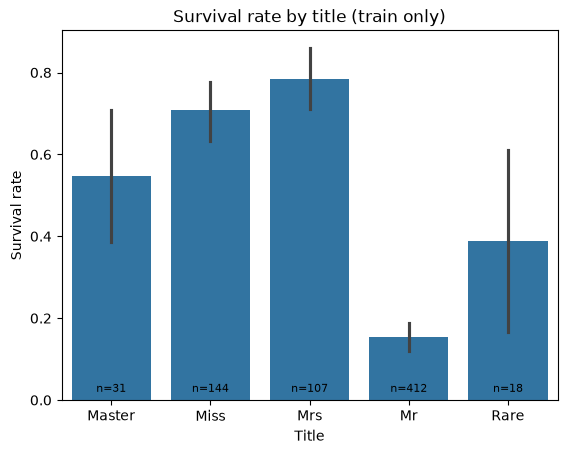

In [3]:
# survival rate by title
order = ["Master", "Miss", "Mrs", "Mr", "Rare"]
ax = sns.barplot(data=rest, x="Title", y="Survived", order=order)
annotate_counts(ax, rest["Title"].value_counts()[order])
plt.ylabel("Survival rate")
plt.title("Survival rate by title (train only)")
plt.show()

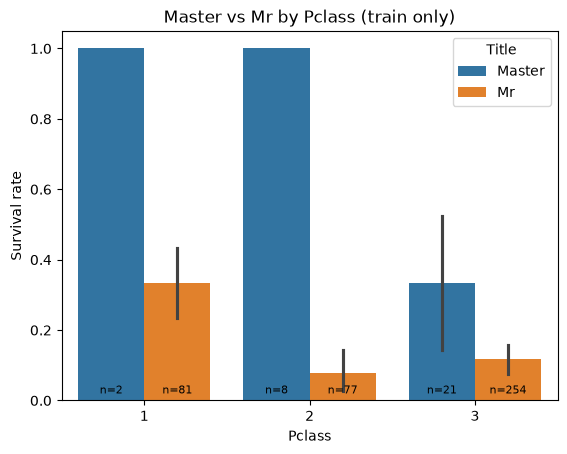

In [4]:
# Master vs Mr -- the same males, split by whether the title marks them as a boy.
# this is the part of Title that Sex cannot already express
males = rest[rest["Title"].isin(["Master", "Mr"])]
ax = sns.barplot(data=males, x="Pclass", y="Survived", hue="Title", hue_order=["Master", "Mr"])
annotate_counts(ax, males.groupby(["Title", "Pclass"]).size()[["Master", "Mr"]])
plt.ylabel("Survival rate")
plt.title("Master vs Mr by Pclass (train only)")
plt.show()

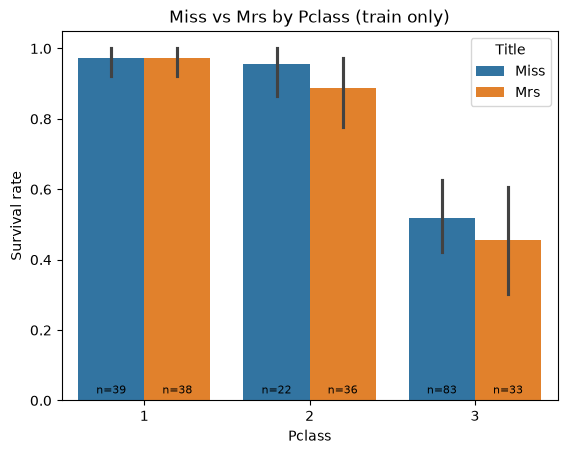

In [5]:
# Miss vs Mrs -- the female equivalent, and the contrast: near-identical inside every class,
# so marital status adds nothing that Sex + Pclass doesn't already say
females = rest[rest["Title"].isin(["Miss", "Mrs"])]
ax = sns.barplot(data=females, x="Pclass", y="Survived", hue="Title", hue_order=["Miss", "Mrs"])
annotate_counts(ax, females.groupby(["Title", "Pclass"]).size()[["Miss", "Mrs"]])
plt.ylabel("Survival rate")
plt.title("Miss vs Mrs by Pclass (train only)")
plt.show()

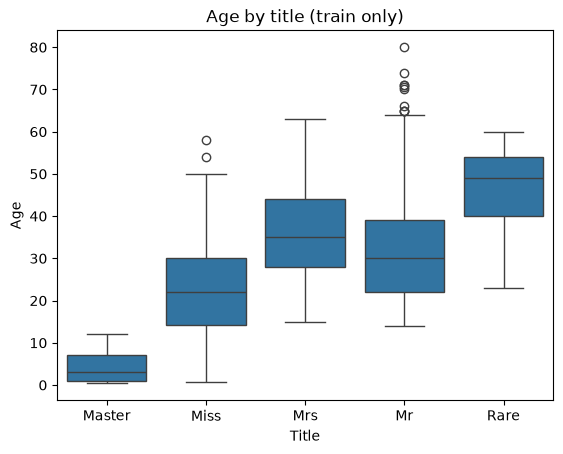

median age -- Title x Pclass (what Title could impute with):
Pclass      1     2     3
Title                    
Master   2.46   1.0   5.0
Miss    30.00  24.0  18.0
Mr      40.00  30.0  27.0
Mrs     39.00  33.5  31.0
Rare    49.00  51.0   NaN

median age -- Sex x Pclass (what the pipeline imputes with today):
Pclass     1     2     3
Sex                     
female  35.0  29.0  21.5
male    40.0  30.0  26.0

rows with Age missing, by title:
Title
Master     3
Miss      26
Mr        94
Mrs       13
Rare       1
dtype: int64


In [6]:
# second use for Title: age. the pipeline imputes Age from the Pclass x Sex median, which
# hands every missing-age boy the adult male median -- Title separates them cleanly
sns.boxplot(data=rest, x="Title", y="Age", order=order)
plt.title("Age by title (train only)")
plt.show()

print("median age -- Title x Pclass (what Title could impute with):")
print(rest.pivot_table(index="Title", columns="Pclass", values="Age", aggfunc="median"))
print("\nmedian age -- Sex x Pclass (what the pipeline imputes with today):")
print(rest.pivot_table(index="Sex", columns="Pclass", values="Age", aggfunc="median"))
print("\nrows with Age missing, by title:")
print(rest[rest["Age"].isna()].groupby("Title").size())

In [7]:
# head-to-head: IsMaster vs the pipeline's existing Under10, with everything else controlled
head_to_head = smf.logit(
    "Survived ~ IsMaster + Under10 + C(Pclass) + C(Sex) + Fare + FamLarge", data=rest
).fit()
print(head_to_head.summary().tables[1])

print("\nmales only -- how the two flags overlap:")
print(rest[rest["Sex"] == "male"].groupby(["IsMaster", "Under10"])["Survived"].agg(["mean", "size"]))

Optimization terminated successfully.
         Current function value: 0.406062
         Iterations 6
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.4466      0.356      6.878      0.000       1.749       3.144
C(Pclass)[T.2]    -1.0760      0.338     -3.182      0.001      -1.739      -0.413
C(Pclass)[T.3]    -1.7992      0.321     -5.602      0.000      -2.429      -1.170
C(Sex)[T.male]    -3.1298      0.240    -13.054      0.000      -3.600      -2.660
IsMaster           3.2166      0.692      4.646      0.000       1.860       4.573
Under10            0.8036      0.533      1.507      0.132      -0.242       1.849
Fare               0.0041      0.003      1.384      0.166      -0.002       0.010
FamLarge          -2.8739      0.519     -5.538      0.000      -3.891      -1.857

males only -- how the two flags overlap:
                      mean

## Age x Sex

Why `Under10` underperforms: youth only helps one sex.

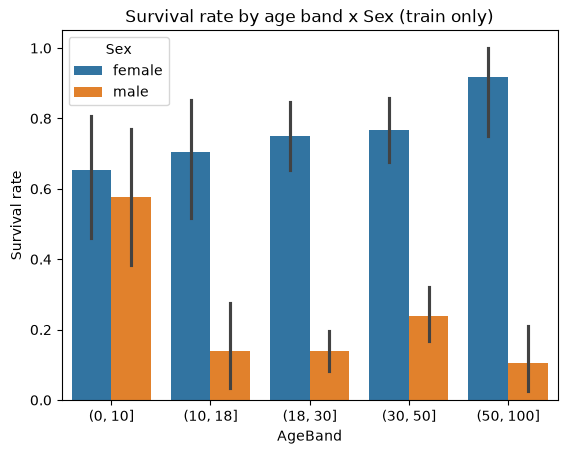

                      mean  size
AgeBand   Sex                   
(0, 10]   female  0.653846    26
          male    0.576923    26
(10, 18]  female  0.703704    27
          male    0.137931    29
(18, 30]  female  0.750000    72
          male    0.139860   143
(30, 50]  female  0.766234    77
          male    0.240000   125
(50, 100] female  0.916667    12
          male    0.105263    38


In [8]:
# survival by age band, split by sex
banded = rest.dropna(subset=["Age"]).assign(
    AgeBand=lambda d: pd.cut(d["Age"], [0, 10, 18, 30, 50, 100])
)
ax = sns.barplot(data=banded, x="AgeBand", y="Survived", hue="Sex")
plt.ylabel("Survival rate")
plt.title("Survival rate by age band x Sex (train only)")
plt.show()

print(banded.groupby(["AgeBand", "Sex"], observed=True)["Survived"].agg(["mean", "size"]))

In [9]:
# the interaction term, formally
age_sex = smf.logit(
    "Survived ~ Age * C(Sex) + C(Pclass)", data=rest.dropna(subset=["Age"])
).fit()
print(age_sex.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.440923
         Iterations 6
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.3961      0.498      6.823      0.000       2.420       4.372
C(Sex)[T.male]        -1.3597      0.490     -2.775      0.006      -2.320      -0.399
C(Pclass)[T.2]        -1.6159      0.340     -4.757      0.000      -2.282      -0.950
C(Pclass)[T.3]        -2.8215      0.335     -8.417      0.000      -3.479      -2.165
Age                   -0.0155      0.013     -1.227      0.220      -0.040       0.009
Age:C(Sex)[T.male]    -0.0418      0.016     -2.572      0.010      -0.074      -0.010


## Ticket

A ticket number is shared by everyone travelling on it, which makes it a group id.

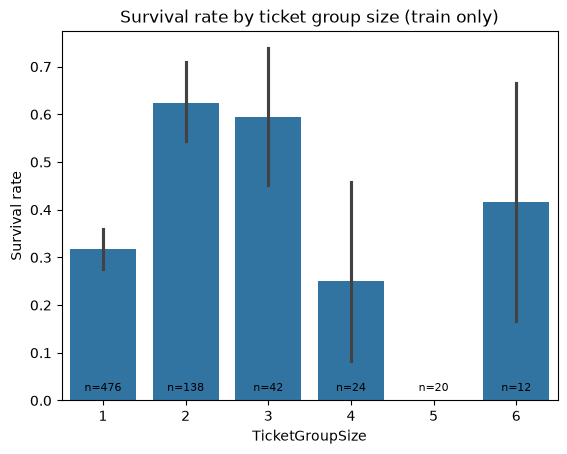

In [10]:
# survival by how many passengers share the ticket
ax = sns.barplot(data=rest, x="TicketGroupSize", y="Survived")
annotate_counts(ax, rest["TicketGroupSize"].value_counts().sort_index())
plt.ylabel("Survival rate")
plt.title("Survival rate by ticket group size (train only)")
plt.show()

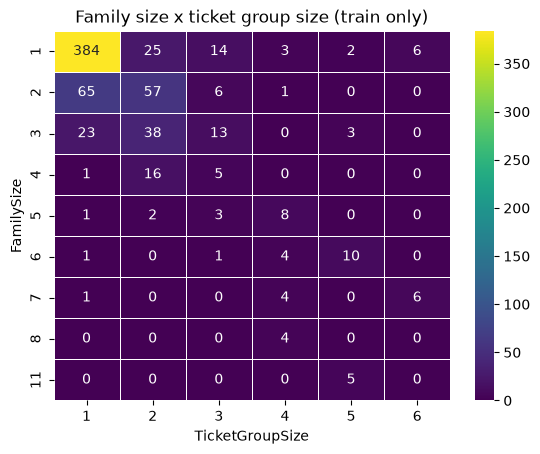

In [11]:
# ticket groups vs the family size the pipeline already buckets. the off-diagonal is the
# question: is a shared ticket telling us anything SibSp + Parch doesn't?
counts = pd.crosstab(rest["FamilySize"], rest["TicketGroupSize"])
sns.heatmap(counts, annot=True, fmt="d", cmap="viridis", linewidths=0.5)
plt.title("Family size x ticket group size (train only)")
plt.show()

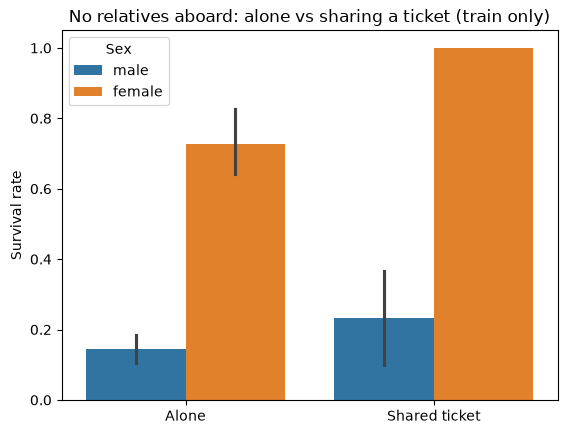

                            mean  size
Sex    SoloWithCompany                
female 0                0.728395    81
       1                1.000000    20
male   0                0.145215   303
       1                0.233333    30
Optimization terminated successfully.
         Current function value: 0.443439
         Iterations 6
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.1685      0.341      6.361      0.000       1.500       2.837
C(Pclass)[T.2]     -0.7265      0.318     -2.288      0.022      -1.349      -0.104
C(Pclass)[T.3]     -1.5316      0.307     -4.991      0.000      -2.133      -0.930
C(Sex)[T.male]     -2.8224      0.220    -12.837      0.000      -3.253      -2.391
SoloWithCompany     0.2005      0.426      0.470      0.638      -0.635       1.036
FamLarge           -1.9968      0.479     -4.172      0.000      -2.935     

In [12]:
# the interesting off-diagonal cell: no relatives aboard, but not travelling alone
ax = sns.barplot(data=rest[rest["FamilySize"] == 1], x="SoloWithCompany", y="Survived", hue="Sex")
plt.xticks([0, 1], ["Alone", "Shared ticket"])
plt.xlabel("")
plt.ylabel("Survival rate")
plt.title("No relatives aboard: alone vs sharing a ticket (train only)")
plt.show()

print(rest[rest["FamilySize"] == 1].groupby(["Sex", "SoloWithCompany"])["Survived"].agg(["mean", "size"]))

solo = smf.logit(
    "Survived ~ SoloWithCompany + FamLarge + C(Pclass) + C(Sex) + Fare", data=rest
).fit()
print(solo.summary().tables[1])

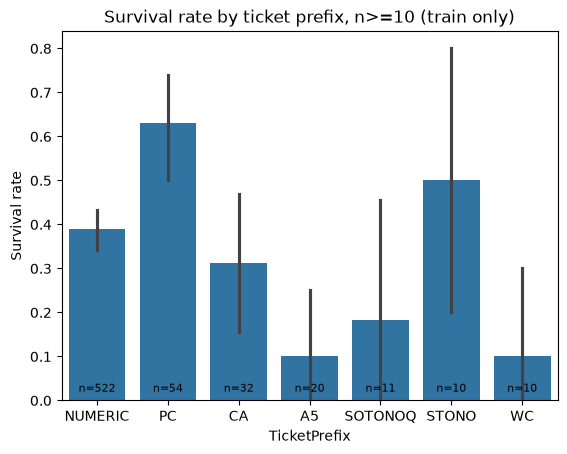

Pclass          1    2    3
TicketPrefix               
False         117  150  391
True           54    0    0
Optimization terminated successfully.
         Current function value: 0.458270
         Iterations 6
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.2516      0.329      6.853      0.000       1.608       2.896
C(Pclass)[T.2]    -0.9182      0.320     -2.874      0.004      -1.545      -0.292
C(Pclass)[T.3]    -1.9106      0.301     -6.356      0.000      -2.500      -1.321
C(Sex)[T.male]    -2.6405      0.208    -12.674      0.000      -3.049      -2.232
PCTicket          -0.4097      0.432     -0.948      0.343      -1.257       0.438
Fare               0.0029      0.003      1.049      0.294      -0.003       0.008


In [13]:
# ticket prefixes with enough rows to say anything
common = rest["TicketPrefix"].value_counts()
common = common[common >= 10].index
ax = sns.barplot(data=rest[rest["TicketPrefix"].isin(common)], x="TicketPrefix", y="Survived", order=common)
annotate_counts(ax, rest["TicketPrefix"].value_counts()[common])
plt.ylabel("Survival rate")
plt.title("Survival rate by ticket prefix, n>=10 (train only)")
plt.show()

# PC is the Pclass proxy people reach for -- it is entirely inside 1st class
print(pd.crosstab(rest["TicketPrefix"].isin(["PC"]), rest["Pclass"]))
pc = smf.logit(
    "Survived ~ PCTicket + C(Pclass) + C(Sex) + Fare",
    data=rest.assign(PCTicket=rest["TicketPrefix"].eq("PC").astype(int)),
).fit()
print(pc.summary().tables[1])

## Fare per person

`Fare` is charged per ticket, not per passenger, so a family of five shows five copies of a
large number. Dividing by the ticket group size should be the more honest measure of wealth.

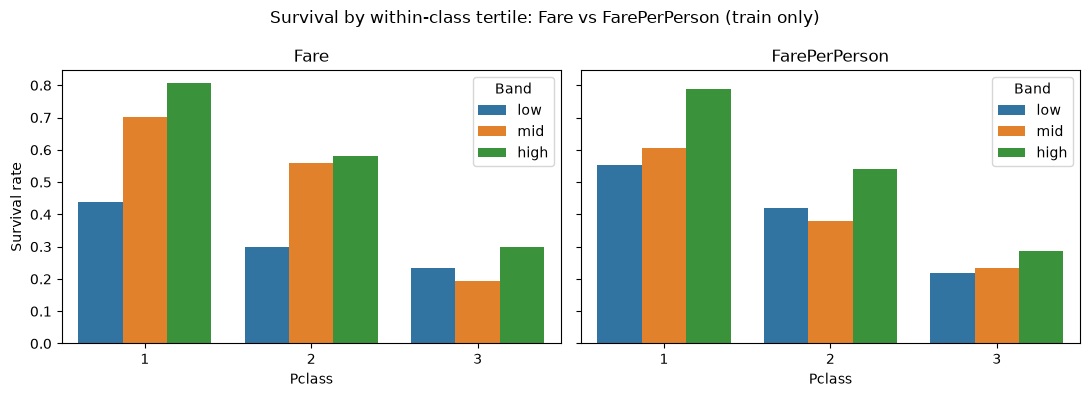

Survived ~ Fare + C(Pclass) + C(Sex)   pseudo R2 = 0.3107
Survived ~ FarePerPerson + C(Pclass) + C(Sex)   pseudo R2 = 0.3101


In [14]:
# within-class tertiles: does per-person fare order survival better than raw fare?
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ["Fare", "FarePerPerson"]):
    banded = rest.assign(
        Band=rest.groupby("Pclass")[col].transform(
            lambda s: pd.qcut(s, 3, labels=["low", "mid", "high"], duplicates="drop")
        )
    )
    sns.barplot(data=banded, x="Pclass", y="Survived", hue="Band", ax=ax, errorbar=None)
    ax.set_title(col)
    ax.set_ylabel("Survival rate")
plt.suptitle("Survival by within-class tertile: Fare vs FarePerPerson (train only)")
plt.tight_layout()
plt.show()

for formula in [
    "Survived ~ Fare + C(Pclass) + C(Sex)",
    "Survived ~ FarePerPerson + C(Pclass) + C(Sex)",
]:
    fitted = smf.logit(formula, data=rest).fit(disp=0)
    print(f"{formula}   pseudo R2 = {fitted.prsquared:.4f}")

## Embarked

Already one-hot encoded in the pipeline -- the question is whether it earns the columns.

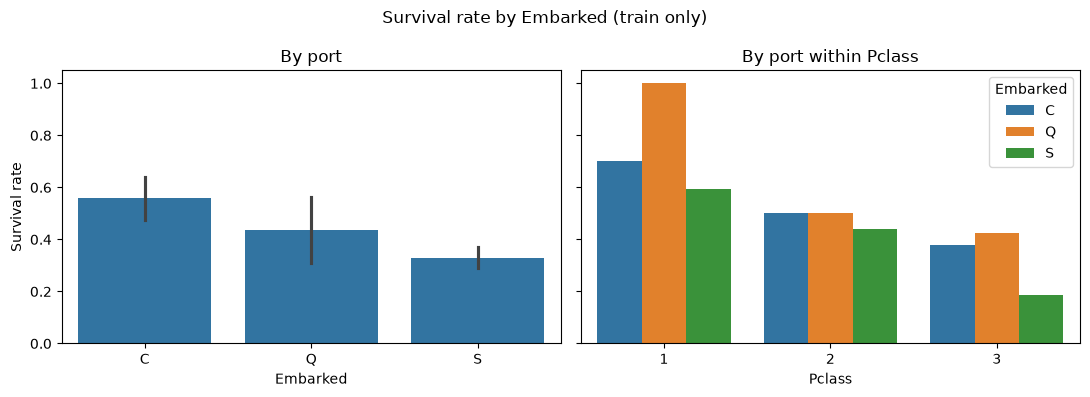

Pclass     1    2    3
Embarked              
C         74   12   53
Q          1    2   52
S         94  136  286


In [15]:
# survival by port, then the same split inside each class
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.barplot(data=rest, x="Embarked", y="Survived", order=["C", "Q", "S"], ax=axes[0])
axes[0].set_title("By port")
axes[0].set_ylabel("Survival rate")
sns.barplot(data=rest, x="Pclass", y="Survived", hue="Embarked", hue_order=["C", "Q", "S"], ax=axes[1], errorbar=None)
axes[1].set_title("By port within Pclass")
plt.suptitle("Survival rate by Embarked (train only)")
plt.tight_layout()
plt.show()

print(pd.crosstab(rest["Embarked"], rest["Pclass"]))

In [16]:
# port, with the things it correlates with controlled for
embarked = smf.logit(
    "Survived ~ C(Embarked) + C(Pclass) + C(Sex) + Fare", data=rest.dropna(subset=["Embarked"])
).fit()
print(embarked.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.454729
         Iterations 6
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.5080      0.372      6.744      0.000       1.779       3.237
C(Embarked)[T.Q]     0.1881      0.420      0.447      0.655      -0.636       1.012
C(Embarked)[T.S]    -0.5434      0.258     -2.106      0.035      -1.049      -0.038
C(Pclass)[T.2]      -0.6833      0.314     -2.175      0.030      -1.299      -0.067
C(Pclass)[T.3]      -1.8289      0.298     -6.127      0.000      -2.414      -1.244
C(Sex)[T.male]      -2.6007      0.210    -12.404      0.000      -3.012      -2.190
Fare                 0.0015      0.003      0.580      0.562      -0.004       0.007


## Interactions among features already in the pipeline

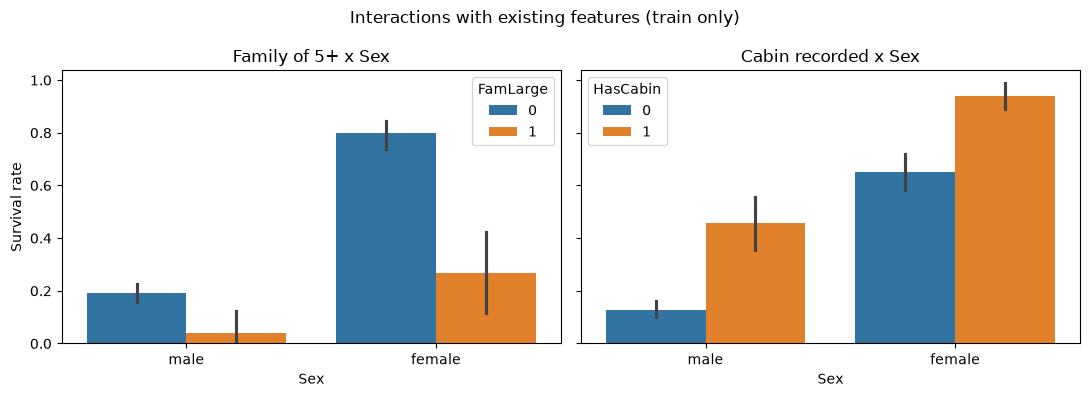

Optimization terminated successfully.
         Current function value: 0.445400
         Iterations 7
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   2.5474      0.260      9.804      0.000       2.038       3.057
C(Sex)[T.male]             -2.8747      0.221    -13.012      0.000      -3.308      -2.442
C(Pclass)[T.2]             -0.9687      0.280     -3.455      0.001      -1.518      -0.419
C(Pclass)[T.3]             -1.8303      0.247     -7.418      0.000      -2.314      -1.347
FamLarge                   -1.9650      0.491     -3.998      0.000      -2.928      -1.002
FamLarge:C(Sex)[T.male]     0.8171      1.152      0.709      0.478      -1.441       3.075


In [17]:
# does a large family sink women and men equally? (FamilyLarge is already a feature)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.barplot(data=rest, x="Sex", y="Survived", hue="FamLarge", ax=axes[0])
axes[0].set_title("Family of 5+ x Sex")
axes[0].set_ylabel("Survival rate")
sns.barplot(data=rest, x="Sex", y="Survived", hue="HasCabin", ax=axes[1])
axes[1].set_title("Cabin recorded x Sex")
plt.suptitle("Interactions with existing features (train only)")
plt.tight_layout()
plt.show()

famsex = smf.logit("Survived ~ FamLarge * C(Sex) + C(Pclass)", data=rest).fit()
print(famsex.summary().tables[1])

## Does any of it move CV accuracy?

Statistical significance is not the same as a better model. Every candidate is scored on the real
`build_preprocessing_pipeline` with the same 5-fold splitter `train.py` uses, on the full
`train.csv` -- so these numbers are comparable to a wandb run.

`is_master` is now a feature the pipeline ships, so these variants are just feature lists plus, for
age imputation, the `group_cols` of the `impute_age` step.

In [18]:
import yaml
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from preprocessing import build_preprocessing_pipeline

MODELS = {
    "logistic_regression": LogisticRegression,
    "random_forest": RandomForestClassifier,
    "gradient_boosting": HistGradientBoostingClassifier,
}
X, y = df.drop(columns=["Survived"]), df["Survived"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# each model family scored on its own config's params, so the numbers match what a run would log
def cv_accuracy(preprocessing, config, model_cls):
    steps = [("pre", preprocessing)]
    if config.get("scale"):
        steps.append(("scale", StandardScaler()))
    steps.append(("model", model_cls(**config.get("params", {}))))
    scores = cross_val_score(Pipeline(steps), X, y, cv=cv, scoring="accuracy")
    return f"{scores.mean():.4f} +/- {scores.std():.3f}"


configs = {name: yaml.safe_load(open(f"configs/{name}.yaml")) for name in MODELS}

### Decomposition: the two winning changes, separately and together

The table above tests `IsMaster` while age imputation still groups on `Sex`. Both accepted changes
touch the same thing -- how the pipeline knows a passenger is a boy -- so they have to be scored as
a 2x2, not one at a time.

In [19]:
# `is_master` on/off x age imputation grouped on Sex/Title, for all three model families
def variant(features, age_by):
    pipe = build_preprocessing_pipeline(features)
    pipe.named_steps["impute_age"].set_params(group_cols=["Pclass", age_by])
    return pipe


OLD_F = ["male_x_3rdclass", "under10", "family_group"]
NEW_F = ["male_x_3rdclass", "is_master", "family_group"]
cells = [
    ("under10   + age~Sex  ", OLD_F, "Sex"),
    ("under10   + age~Title", OLD_F, "Title"),
    ("is_master + age~Sex  ", NEW_F, "Sex"),
    ("is_master + age~Title", NEW_F, "Title"),
]

for name, config in configs.items():
    # tolerate a config whose `model:` has been edited to something not in MODELS
    model_cls = MODELS.get(config["model"], MODELS[name])
    print(f"--- {name} ---")
    for label, features, age_by in cells:
        print(f"  {label}  {cv_accuracy(variant(features, age_by), config, model_cls)}")
    print()

--- logistic_regression ---


  under10   + age~Sex    0.8294 +/- 0.013


  under10   + age~Title  0.8283 +/- 0.017
  is_master + age~Sex    0.8361 +/- 0.013


  is_master + age~Title  0.8350 +/- 0.011

--- random_forest ---


  under10   + age~Sex    0.8159 +/- 0.021


...

  is_master + age~Title  0.8182 +/- 0.021

--- gradient_boosting ---


  under10   + age~Sex    0.8372 +/- 0.019


  under10   + age~Title  0.8384 +/- 0.026


  is_master + age~Sex    0.8451 +/- 0.018


  is_master + age~Title  0.8339 +/- 0.025



### The rejected variant: one-hot the whole `Title`

Kept here because "just one-hot the title" is the obvious thing to reach for, and it is worse than
the single `IsMaster` column it would replace.

In [20]:
# Title is a working column now, so this variant has to cancel the drop_title step and
# hand Title to the one-hot encoder instead
def title_onehot(features):
    pipe = build_preprocessing_pipeline(features)
    steps = [(name, step) for name, step in pipe.steps if name != "drop_title"]
    one_hot = steps[-1][1]
    name, encoder, columns = one_hot.transformers[0]
    one_hot.transformers[0] = (name, encoder, columns + ["Title"])
    return Pipeline(steps)


for name in ["logistic_regression", "gradient_boosting"]:
    config, model_cls = configs[name], MODELS.get(configs[name]["model"], MODELS[name])
    shipped = cv_accuracy(variant(NEW_F, "Sex"), config, model_cls)
    onehot = cv_accuracy(title_onehot(["male_x_3rdclass", "under10", "family_group"]), config, model_cls)
    print(f"{name:20s}  IsMaster {shipped}   full Title one-hot {onehot}")

logistic_regression   IsMaster 0.8361 +/- 0.013   full Title one-hot 0.8339 +/- 0.008


gradient_boosting     IsMaster 0.8451 +/- 0.018   full Title one-hot 0.8417 +/- 0.020


## Conclusions

**Worth adding**

- **`IsMaster`** (title == "Master", i.e. a boy) — the single best thing left in the data. It beats
  `Under10` on its own terms: with both in one model, `IsMaster` is significant and `Under10` is
  not, and swapping one for the other is the only change here that moves CV accuracy for both
  model families. It also works where `Under10` can't — a boy with a missing `Age` gets the adult
  male median from the imputer and so fails the `< 10` test, while his title still says "Master".
- **Age imputation by `Title`** instead of `Sex` — same reason, one level up. The current
  `Pclass x Sex` median gives a missing-age boy ~26-30 years; `Master` medians are 1-5.
  **But see the decomposition above:** it only pays off *without* `IsMaster`. With both on, the
  imputed age is a near-duplicate of the flag and the tree models lose a split they were using
  (gb 0.8451 -> 0.8339). The whole train set holds only 4 missing-age Masters, so the case it was
  aimed at is tiny, while the other 173 imputed rows move for nothing. Shipped state: `is_master` is on and
  `impute_age` stays grouped on `Sex` -- the best-scoring pair for all three model families.

**Tested and rejected**

- **Full `Title` one-hot** — `Miss` vs `Mrs` is flat inside every class, so the extra columns are
  a re-encoding of `Sex`. Only the `Master` level carries new information.
- **Ticket group size** — real signal in isolation, but it collapses next to the family-size
  buckets already in the pipeline. The one genuinely new group it finds (no relatives aboard, but
  sharing a ticket) is 50 rows and doesn't survive controls.
- **Ticket prefix** — `PC` is entirely inside 1st class; it's `Pclass` spelled differently.
- **`FarePerPerson`** — the more principled measure, but no better than `Fare` once `Pclass` is in.
- **`Embarked`** — keep the one-hot columns it already has; `S` stays negative under controls. No
  change needed.

**Deliberately not pursued**

- **Surname-based family survival** ("did this passenger's relatives live?"). It is the strongest
  remaining feature on paper and the reason it wins Kaggle notebooks, but the target of one row
  becomes a feature of another. Done naively inside `fit()` it leaks; done properly it needs
  out-of-fold construction. Not worth the machinery here.